In [101]:
import numpy as np

for delta in [0.1, 1.0]:
    
    # === 1. Set structural parameters ===
    alpha = 0.33
    beta  = 0.99
    rho   = 0.95     # AR(1) coefficient for z_t
    sigma = 0.01

    # === 2. Compute steady state (non-stochastic, z = 0) ===
    # From: 1 - beta(1-delta) = alpha * beta * k^{alpha-1}
    k_ss = ((1 - beta * (1 - delta)) / (alpha * beta)) ** (1 / (alpha - 1))
    c_ss = k_ss**alpha - delta * k_ss

    print("Steady state k̄ =", k_ss)
    print("Steady state c̄ =", c_ss)

    # === 3. Build matrices B, C, D, E ===
    # Ordering of state/control vector: x = [ĉ_t, k̂_t]'

    B = np.array([
        [-1.0, (1 - beta * (1 - delta)) * (alpha - 1.0)],
        [ 0.0, -k_ss]
    ])

    C = np.array([
        [ 1.0,                           0.0],
        [-c_ss, alpha * (k_ss ** (alpha)) + (1 - delta) * k_ss]
    ])

    D = np.array([
        [1 - beta * (1 - delta)],
        [0.0]
    ])

    E = np.array([
        [0.0],
        [k_ss ** alpha]
    ])

    # === 4. Compute H and its eigenvalues ===
    B_inv = np.linalg.inv(B)

    H = -B_inv @ C
    eigvals, eigvecs = np.linalg.eig(H)

    print("\nMatrix H =")
    print(H)

    print("\nEigenvalues of H =")
    print(eigvals)

    # === 5. Compute G ===
    # Recall: G = -B^{-1} (D * rho + E)
    G = -B_inv @ (D * rho + E)
    print("\nMatrix G =")
    print(G)
    # Store results for different delta
    if delta == 0.1:
        H_delta_01 = H
        G_delta_01 = G
        eigvals_delta_01 = eigvals
        k_ss_delta_01 = k_ss
        c_ss_delta_01 = c_ss
    else:
        H_delta_1 = H
        G_delta_1 = G
        eigvals_delta_1 = eigvals
        k_ss_delta_1 = k_ss
        c_ss_delta_1 = c_ss

# ---------------------------------------------------------------------------------
# Summary of results
# Print latex matrices for H and G
def matrix_to_latex(mat, name):
    latex_str =  f"\\[{name} = \\begin{{bmatrix}}\n"
    for row in mat:
        latex_str += " & ".join([f"{val:.4f}" for val in row]) + " \\\\\n"
    latex_str += "\\end{bmatrix}\\]"
    return latex_str

# Store results in ouptut folder
with open("output/matrices_latex.txt", "w") as f:
    f.write(matrix_to_latex(H_delta_01, "H") + "\n\n")
    f.write(matrix_to_latex(G_delta_01, "G") + "\n\n")
    f.write("\\noindent Eigenvalues of H:\n")
    f.write(", ".join([f"{val:.4f}" for val in eigvals_delta_01]) + "\n\n")

    f.write(matrix_to_latex(H_delta_1, "H") + "\n\n")
    f.write(matrix_to_latex(G_delta_1, "G") + "\n\n")
    f.write("\\noindent Eigenvalues of H:\n")
    f.write(", ".join([f"{val:.4f}" for val in eigvals_delta_1]) + "\n")


Steady state k̄ = 5.1466700074364695
Steady state c̄ = 1.2024650188785602

Matrix H =
[[ 1.01706269 -0.07376768]
 [-0.23363942  1.01010101]]

Eigenvalues of H =
[1.14491027 0.88225343]

Matrix G =
[[0.07918431]
 [0.33363942]]
Steady state k̄ = 0.18829962470684933
Steady state c̄ = 0.38806898474172524

Matrix H =
[[ 2.38081114 -0.67676768]
 [-2.06091215  1.01010101]]

Eigenvalues of H =
[3.06091215 0.33      ]

Matrix G =
[[-1.10081114]
 [ 3.06091215]]


Policy coefficients for ĉ_t:
p_k (c on k): 0.5472003763153923
p_z (c on z): 0.530414876503458

Transition for k̂_t:
A_s (k on k(-1)): 0.8822534290659508
B_s (k on z(-1)): 0.20971359803027562


/var/folders/mz/9j0q2hw52gn0z79drwg1nbsw0000gn/T/ipykernel_70769/928233607.py:53: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  g1 = float(G[0])
/var/folders/mz/9j0q2hw52gn0z79drwg1nbsw0000gn/T/ipykernel_70769/928233607.py:54: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  g2 = float(G[1])


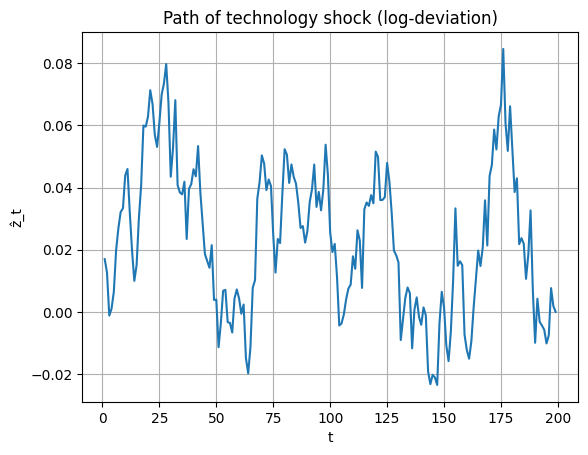

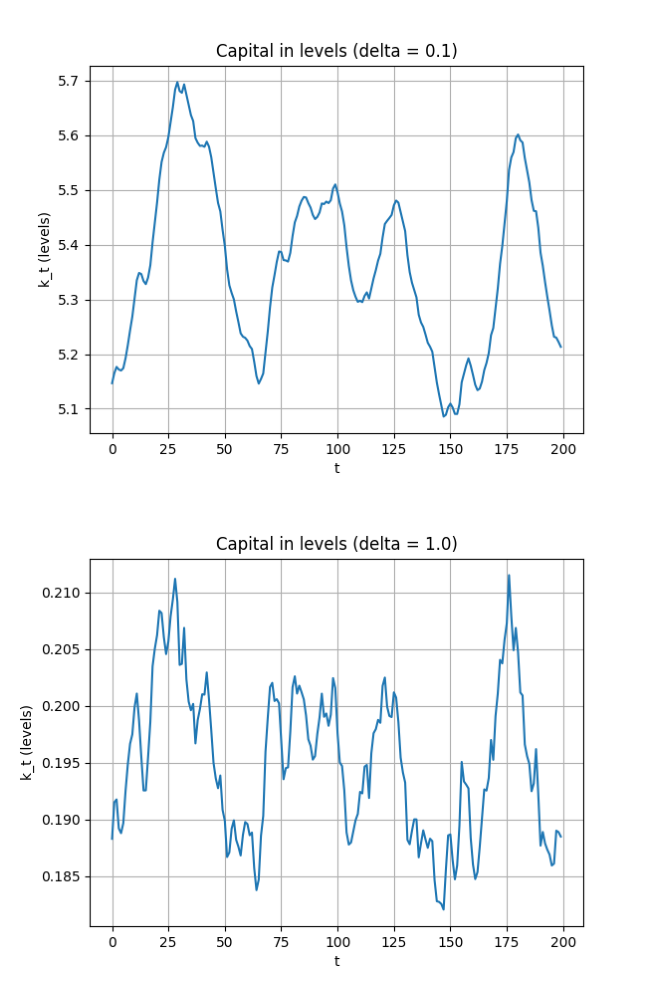

Implied Dynare-style coefficients:
c on k(-1): 0.12784758103505933
c on z(-1): 0.6378053344881998
k on k(-1): 0.8822534290659508
k on z(-1): 1.0793266851340073
[1.14491027 0.88225343 0.95      ]


In [110]:
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

# Given H and G from previous computations
T = 200        # number of periods
np.random.seed(0)  # for reproducibility (optional)
delta = 0.1

if delta == 0.1:
    k_ss = k_ss_delta_01  # steady state capital for delta = 0.1
    H = H_delta_01
    G = G_delta_01
    c_ss = c_ss_delta_01 

if delta == 1.0:
    k_ss = k_ss_delta_1  # steady state capital for delta = 1.0
    H = H_delta_1
    G = G_delta_1
    c_ss = c_ss_delta_01 

# ==== Storage for simulated paths ====
z_hat = np.zeros(T+1)          # deviations of z_t from steady state
x_hat = np.zeros((T+1, 2))     # [ĉ_t, k̂_t]'

# start at steady state: all hats = 0
z_hat[0]   = 0.0
x_hat[0,:] = 0.0

# ==== Simulate ====
# Import from MATLAB generated data
import numpy as np
from scipy.io import loadmat

data = loadmat('z_sim.mat')   # use raw string or double backslash
z_hat = np.squeeze(data['z_sim'])   # make it 1D: shape (T+1,) or (T,)
t_grid = np.arange(1,200)

z_hat = z_hat[1:200]
plt.figure()
plt.plot(t_grid, z_hat)
plt.xlabel("t")
plt.ylabel("ẑ_t")
plt.title("Path of technology shock (log-deviation)")
plt.grid(True)       


# ---------------------------------------------------------
# 1. Extract elements of H and G
# ---------------------------------------------------------
h11, h12 = H[0, 0], H[0, 1]
h21, h22 = H[1, 0], H[1, 1]
g1 = float(G[0])
g2 = float(G[1])

# ---------------------------------------------------------
# 2. Solve for policy rule ĉ_t = p_k k̂_t + p_z z_t
# ---------------------------------------------------------
def equations(vars):
    pk, pz = vars

    # from matching ĉ_{t+1} via H and via policy
    # Eq 1: coefficient on k̂_t
    eq1 = h11 * pk + h12 - pk * (h21 * pk + h22)

    # Eq 2: coefficient on z_t
    eq2 = h11 * pz + g1 - (pk * (h21 * pz + g2) + pz * rho)

    return [eq1, eq2]

# initial guess
pk0, pz0 = 0.1, 0.1
p_k, p_z = fsolve(equations, (pk0, pz0))

print("Policy coefficients for ĉ_t:")
print("p_k (c on k):", p_k)
print("p_z (c on z):", p_z)

# ---------------------------------------------------------
# 3. Build k̂ transition: k̂_{t+1} = A_s k̂_t + B_s z_t
# ---------------------------------------------------------
A_s = h21 * p_k + h22
B_s = h21 * p_z + g2

print("\nTransition for k̂_t:")
print("A_s (k on k(-1)):", A_s)
print("B_s (k on z(-1)):", B_s)

# (these should match Dynare's ~0.8888 and ~0.9863)

# ---------------------------------------------------------
# 4. Simulate starting from steady state (all hats = 0)
# ---------------------------------------------------------
# Import from MATLAB generated Z_t
T_sim = 200
k_hat = np.zeros(T_sim)
c_hat = np.zeros(T_sim)

for t in range(T_sim-1):
    k_hat[t+1] = A_s * k_hat[t] + B_s * z_hat[t] # Capital transition in hats
    c_hat[t] = p_k * k_hat[t] + p_z * z_hat[t] # Consumption policy in hats

c_hat[-1] = p_k * k_hat[-1] + p_z * z_hat[-1] # last period consumption

# ---------------------------------------------------------
# 5. Plot K in levels
# ---------------------------------------------------------
t_grid = np.arange(T_sim)
k_level = k_ss * np.exp(k_hat)

# Plot capital in levels for both delta and save to output folder
if delta == 0.1:
    plt.figure()
    plt.plot(t_grid, k_level)
    plt.xlabel("t")
    plt.ylabel("k_t (levels)")
    plt.title("Capital in levels (delta = 0.1)")
    plt.grid(True)
    plt.savefig("output/capital_levels_delta_01.png")
    plt.close()

if delta == 1.0:
    plt.figure()
    plt.plot(t_grid, k_level)
    plt.xlabel("t")
    plt.ylabel("k_t (levels)")
    plt.title("Capital in levels (delta = 1.0)")
    plt.grid(True)
    plt.savefig("output/capital_levels_delta_1.png")
    plt.close()

# Create a 2*1 subplot to compare both deltas
# Load both figures
import matplotlib.image as mpimg
img1 = mpimg.imread("output/capital_levels_delta_01.png")
img2 = mpimg.imread("output/capital_levels_delta_1.png")
fig, axs = plt.subplots(2, 1, figsize=(8, 10))
axs[0].imshow(img1)
axs[0].axis('off')  # Hide axes
axs[1].imshow(img2)
axs[1].axis('off')  # Hide axes
plt.tight_layout()
plt.savefig("output/capital_levels_comparison.png")
plt.show()

# ---------------------------------------------------------
# Compare to Dynare-style coefficients

#1. Policy coefficients
c_ss = c_ss_delta_01  
k_ss = k_ss_delta_01

# Implied Dynare level coefficients from your hat solution:
c_k_level = (c_ss * p_k) / k_ss      # coef on k(-1) in c eq.
c_z_level = c_ss * p_z               # coef on z(-1) in c eq.
k_k_level = A_s                      # coef on k(-1) in k eq.
k_z_level = k_ss * B_s               # coef on z(-1) in k eq.

print("Implied Dynare-style coefficients:")
print("c on k(-1):", c_k_level)
print("c on z(-1):", c_z_level)
print("k on k(-1):", k_k_level)
print("k on z(-1):", k_z_level)

#2. Eigenvalues 
M = np.block([
    [H, G],
    [np.zeros((1,2)), np.array([[rho]])]
])
eigvals_full, _ = np.linalg.eig(M)
print(eigvals_full)



### Implicit function theorem 


In [15]:

# === Parameters ===
alpha = 0.3    # capital share
beta  = 0.96   # discount factor
delta = 0.08   # depreciation
rho   = 0.9    # AR(1) persistence

# Put params in a dict for convenience
params = dict(alpha=alpha, beta=beta, delta=delta, rho=rho)

# === Utility and production ===
def u_c(c):
    return 1.0 / c           # log utility

def f(k, alpha):
    return k**alpha

def f_k(k, alpha):
    return alpha * k**(alpha - 1.0)

# === Equilibrium system H = [Euler residual, Resource residual] ===
def H_vec(c, cp, k, kp, z, lam, params):
    alpha = params["alpha"]
    beta  = params["beta"]
    delta = params["delta"]
    rho   = params["rho"]

    # next-period z under certainty equivalence
    z_next = rho * z   # lam and shocks only matter at higher order

    # return on capital
    R_next = 1.0 + np.exp(z_next) * f_k(kp, alpha) - delta

    # Euler residual
    euler_res = 1.0 - beta * R_next * u_c(cp) / u_c(c)

    # Resource constraint residual
    resource_res = c + kp - np.exp(z) * f(k, alpha) - (1.0 - delta) * k

    return np.array([euler_res, resource_res])

k_star = k_bar
c_star = c_bar

def numerical_H_i(c_star, k_star, params, h=1e-6):
    """
    Compute H1,...,H6 numerically at (c*, c*, k*, k*, z=0, λ=0)
    using two-sided finite differences.

    Returns:
        H1,...,H6 as 2x1 numpy arrays.
    """
    # base point
    x0 = np.array([c_star, c_star, k_star, k_star, 0.0, 0.0])  # [c, cp, k, kp, z, lam]

    def H_at(x):
        return H_vec(x[0], x[1], x[2], x[3], x[4], x[5], params)

    H0 = H_at(x0)  # should be ~ (0,0)

    n_args = len(x0)     # 6
    dim_H  = len(H0)     # 2

    # Jacobian: 2 x 6
    J = np.zeros((dim_H, n_args))

    for j in range(n_args):
        step = np.zeros_like(x0)
        step[j] = h

        Hp = H_at(x0 + step)
        Hm = H_at(x0 - step)

        # 2-sided derivative wrt argument j
        J[:, j] = (Hp - Hm) / (2.0 * h)

    # Split columns into H1,...,H6 (each is 2x1)
    H1 = J[:, [0]]  # dH/dc
    H2 = J[:, [1]]  # dH/dcp
    H3 = J[:, [2]]  # dH/dk
    H4 = J[:, [3]]  # dH/dkp
    H5 = J[:, [4]]  # dH/dz
    H6 = J[:, [5]]  # dH/dλ

    return H1, H2, H3, H4, H5, H6

# Example usage:
H1, H2, H3, H4, H5, H6 = numerical_H_i(c_star, k_star, params)

print("H1 = dH/dc at steady state:\n", H1)
print("H2 = dH/dc' at steady state:\n", H2)
print("H3 = dH/dk at steady state:\n", H3)
print("H4 = dH/dk' at steady state:\n", H4)
print("H5 = dH/dz at steady state:\n", H5)
print("H6 = dH/dλ at steady state:\n", H6)





H1 = dH/dc at steady state:
 [[-3.24645706]
 [ 1.        ]]
H2 = dH/dc' at steady state:
 [[3.24645706]
 [0.        ]]
H3 = dH/dk at steady state:
 [[ 0.      ]
 [-1.885443]]
H4 = dH/dk' at steady state:
 [[3.44545399]
 [1.        ]]
H5 = dH/dz at steady state:
 [[-0.83414275]
 [-0.60597518]]
H6 = dH/dλ at steady state:
 [[0.]
 [0.]]
